# 04. Modeling, Evaluation, and Report Figures

Run strict temporal modeling with graph-only, text-only, and hybrid feature sets. Export metrics, feature importance, and report-ready figures.

In [1]:
from pathlib import Path
import importlib
import sys

root = Path.cwd()
if not (root / 'data').exists():
    root = root.parent
sys.path.insert(0, str(root))

import src.phase3 as phase3
from src.visualization import export_report_figures
phase3 = importlib.reload(phase3)

phase1_path = root / 'data' / 'processed' / 'phase1_kcore_filtered.csv'
phase3_dir = root / 'data' / 'processed' / 'phase3'
figure_dir = root / 'reports' / 'figures'
phase3_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)
phase1_path

WindowsPath('H:/chuong_trinh_hoc_UEH/mon_hoc_ki_6/social_media_data_analysis/Project/Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning/data/processed/phase1_kcore_filtered.csv')

In [2]:
interactions = phase3.load_phase1_interactions(phase1_path)
metrics_frame, importance_frame, score_frame, splits = phase3.run_phase3_pipeline(interactions)
paths = phase3.export_phase3_outputs(metrics_frame, importance_frame, phase3_dir, score_frame)
figure_paths = export_report_figures(interactions, metrics_frame, importance_frame, figure_dir, score_frame)

{
    'train_rows': len(splits.train),
    'validation_rows': len(splits.validation),
    'test_rows': len(splits.test),
    'metric_rows': len(metrics_frame),
    'importance_rows': len(importance_frame),
    'score_rows': len(score_frame),
    'export_paths': {key: str(value) for key, value in paths.items()},
    'figure_count': len(figure_paths),
}

{'train_rows': 25045,
 'validation_rows': 26450,
 'test_rows': 24185,
 'metric_rows': 29,
 'importance_rows': 1756,
 'score_rows': 1468415,
 'export_paths': {'metrics': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\data\\processed\\phase3\\phase3_model_metrics.csv',
  'importance': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\data\\processed\\phase3\\phase3_feature_importance.csv',
  'scores': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\data\\processed\\phase3\\phase3_prediction_scores.csv'},
 'figure_count': 9}

In [3]:
metrics_frame.head(29)

,feature_set,model,validation_roc_auc,validation_pr_auc,validation_f1,validation_macro_f1,validation_precision,validation_recall,validation_balanced_accuracy,validation_accuracy,...,test_precision,test_recall,test_balanced_accuracy,test_accuracy,test_threshold,test_tn,test_fp,test_fn,test_tp,n_features
0,graph_no_balance,random_forest,0.764721,0.183197,0.271628,0.585243,0.190352,0.474026,0.661287,0.822382,...,0.194428,0.393005,0.635453,0.844077,0.46,19751,2747,1024,663,39
1,graph_only,random_forest,0.764838,0.187757,0.270769,0.584307,0.189166,0.476190,0.661435,0.820794,...,0.194203,0.397155,0.636794,0.843002,0.46,19718,2780,1017,670,44
2,hybrid_no_balance,random_forest,0.764363,0.181727,0.261941,0.566455,0.171149,0.557900,0.677475,0.780340,...,0.173767,0.522229,0.668017,0.793467,0.37,18309,4189,806,881,128
3,hybrid,logistic_regression,0.751985,0.179647,0.261060,0.587720,0.196708,0.387987,0.634486,0.846541,...,0.197925,0.418494,0.645664,0.841141,0.69,19637,2861,981,706,133
4,hybrid_no_balance,logistic_regression,0.751337,0.181742,0.260193,0.589143,0.200292,0.371212,0.629940,0.852514,...,0.200416,0.399526,0.640002,0.846930,0.70,19809,2689,1013,674,128
5,hybrid,random_forest,0.765769,0.183562,0.268648,0.578575,0.182524,0.508658,0.668767,0.806503,...,0.186303,0.461174,0.655069,0.821914,0.40,19100,3398,909,778,133
6,graph_only,logistic_regression,0.748142,0.175717,0.258788,0.576565,0.179714,0.462121,0.651839,0.815047,...,0.179124,0.487255,0.659909,0.808476,0.62,18731,3767,865,822,44
7,graph_no_balance,logistic_regression,0.747119,0.177111,0.255293,0.574458,0.177162,0.456710,0.648687,0.813837,...,0.177454,0.484292,0.657983,0.807443,0.62,18711,3787,870,817,39
8,text_only,random_forest,0.694329,0.141009,0.207943,0.546313,0.143385,0.378247,0.604252,0.798677,...,0.155135,0.384114,0.613628,0.811123,0.36,18969,3529,1039,648,89
9,history_only,logistic_regression,0.692645,0.138749,0.223002,0.561968,0.161345,0.360931,0.610004,0.824272,...,0.169586,0.378779,0.619850,0.827290,0.54,19369,3129,1048,639,6


In [4]:
importance_frame.head(30)

,feature_set,model,feature,importance
1576,graph_no_balance,dummy_most_frequent,interaction_count,0.0
1577,graph_no_balance,dummy_most_frequent,positive_count,0.0
1578,graph_no_balance,dummy_most_frequent,negative_count,0.0
1579,graph_no_balance,dummy_most_frequent,sentiment_balance,0.0
1580,graph_no_balance,dummy_most_frequent,negative_ratio,0.0
1581,graph_no_balance,dummy_most_frequent,reciprocal_edge,0.0
1582,graph_no_balance,dummy_most_frequent,source_community_size,0.0
1583,graph_no_balance,dummy_most_frequent,source_clustering_coefficient,0.0
1584,graph_no_balance,dummy_most_frequent,source_in_degree,0.0
1585,graph_no_balance,dummy_most_frequent,source_out_degree,0.0


## Direct Report Figures

The generated report figures are displayed below so the notebook is self-contained for review.

model_comparison_pr_auc.png


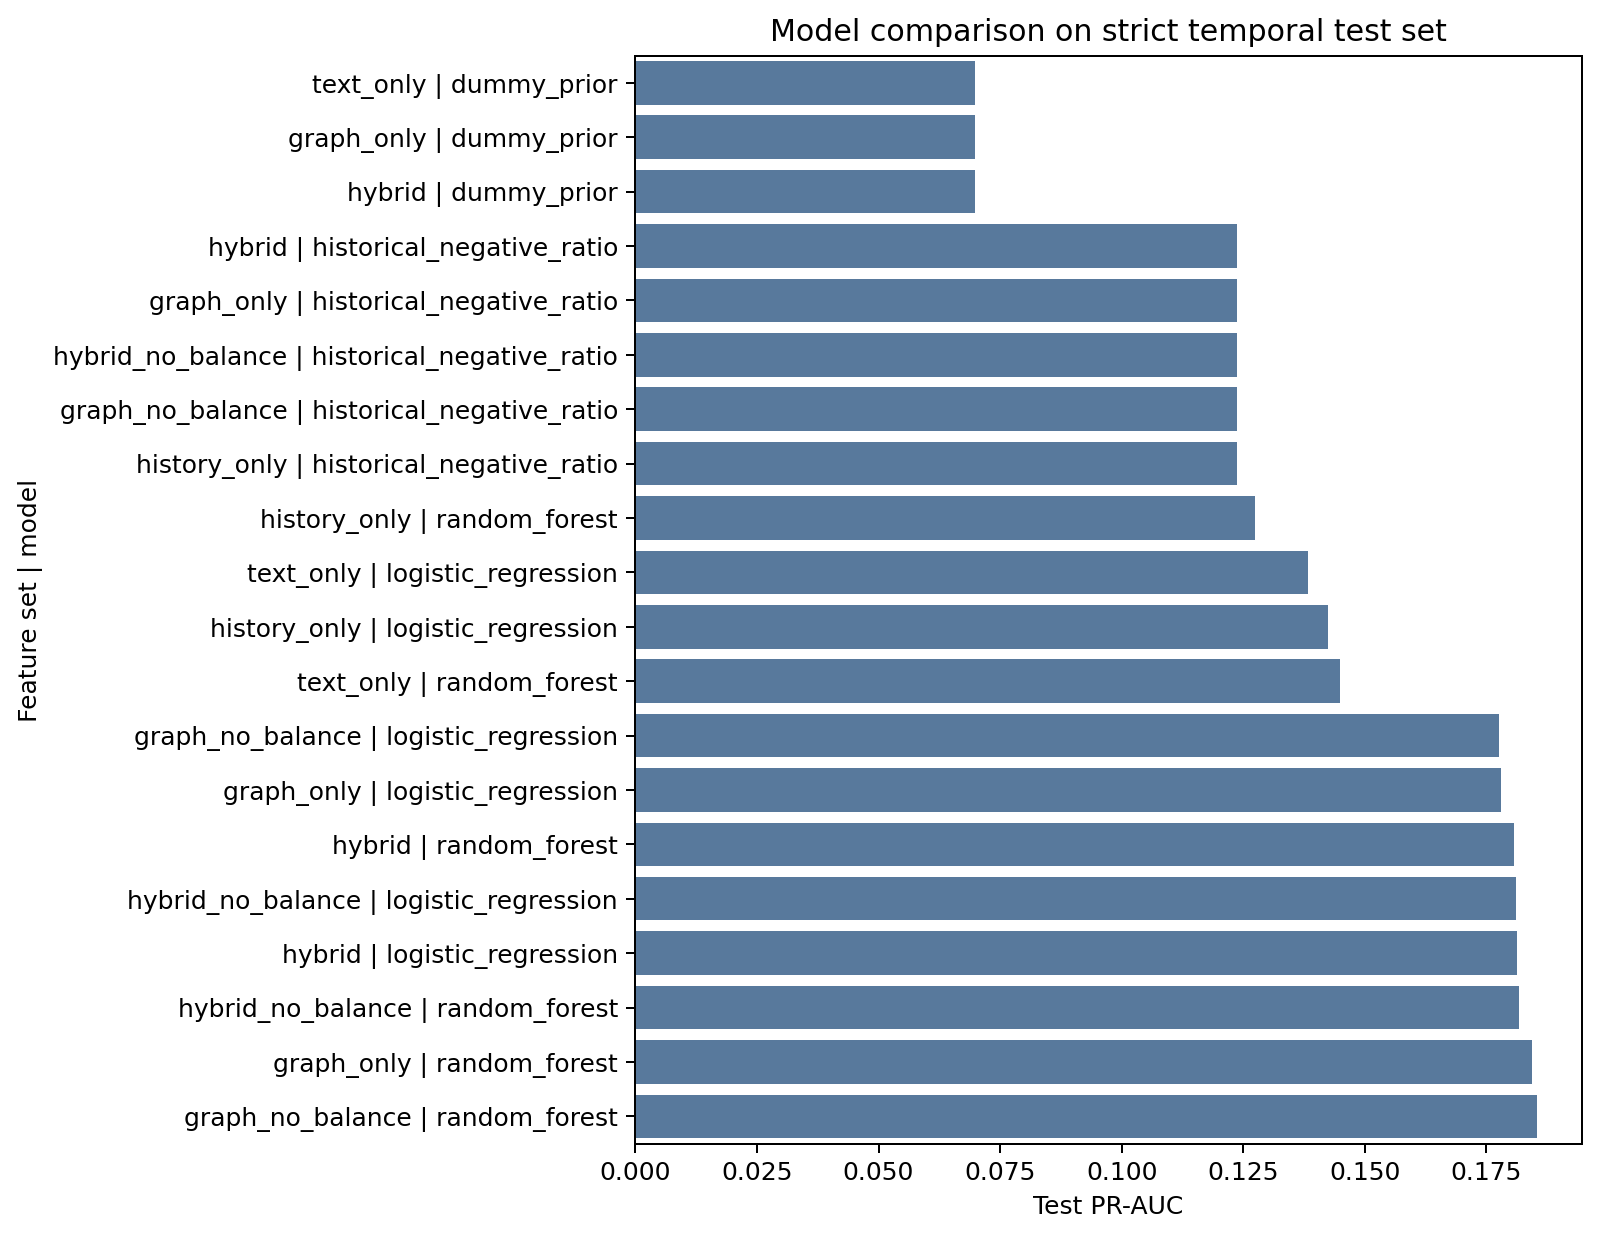

precision_recall_curve.png


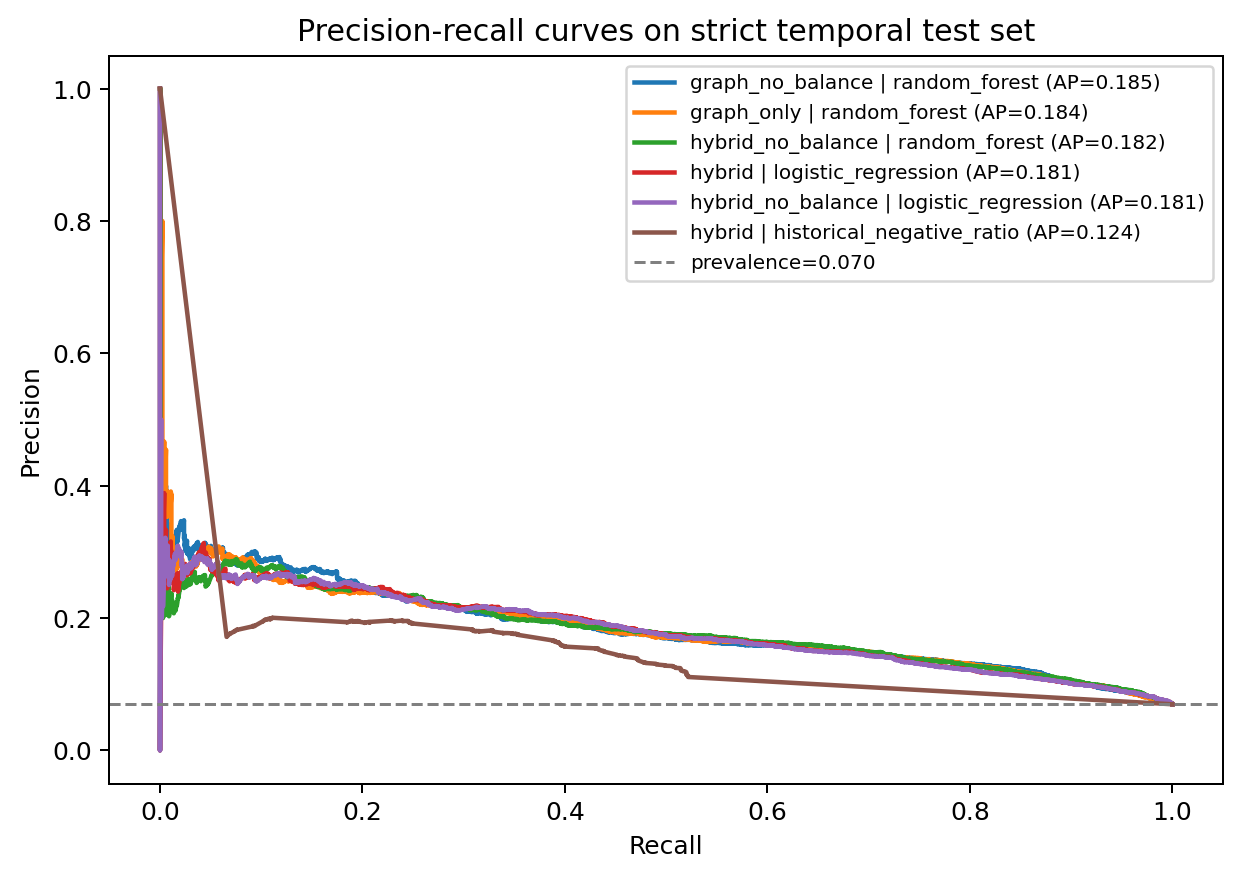

roc_curve.png


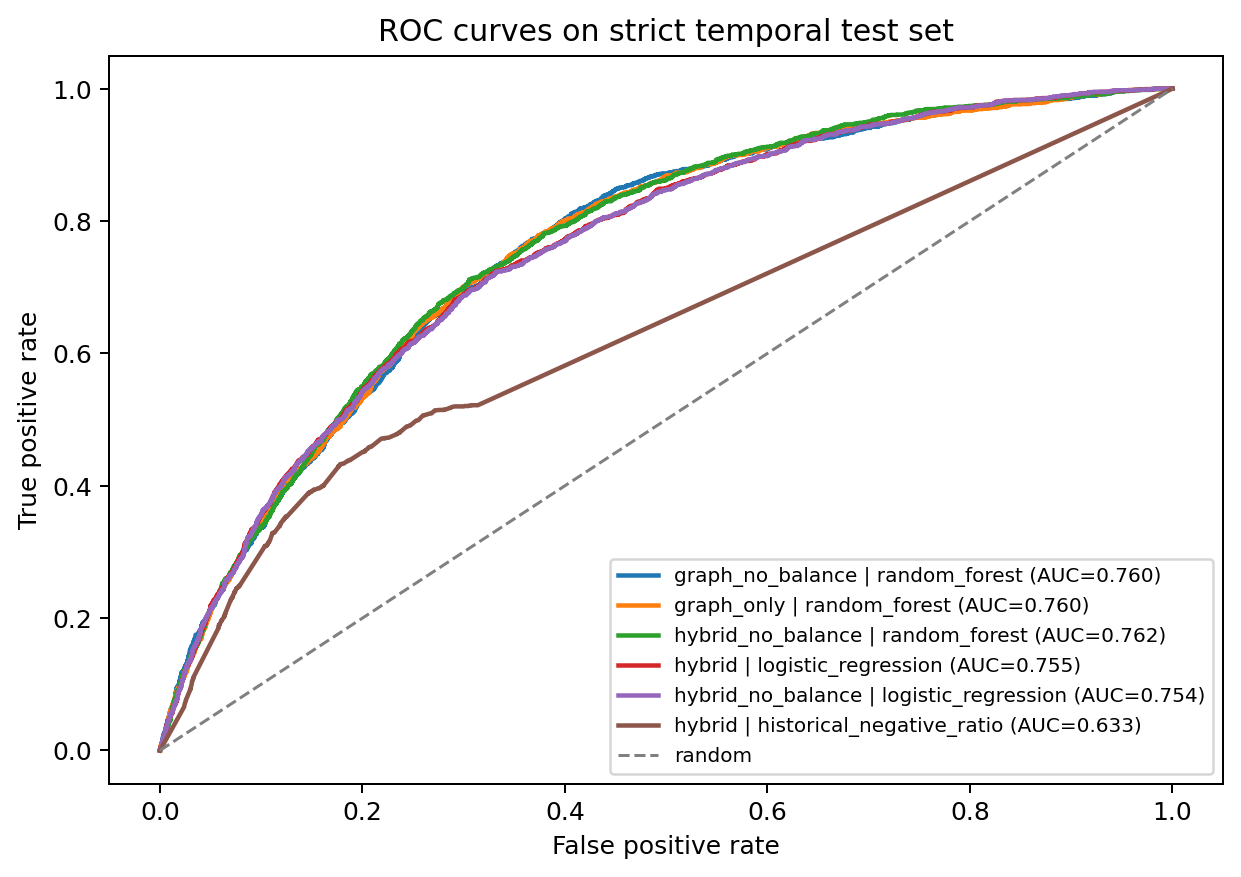

best_confusion_matrix.png


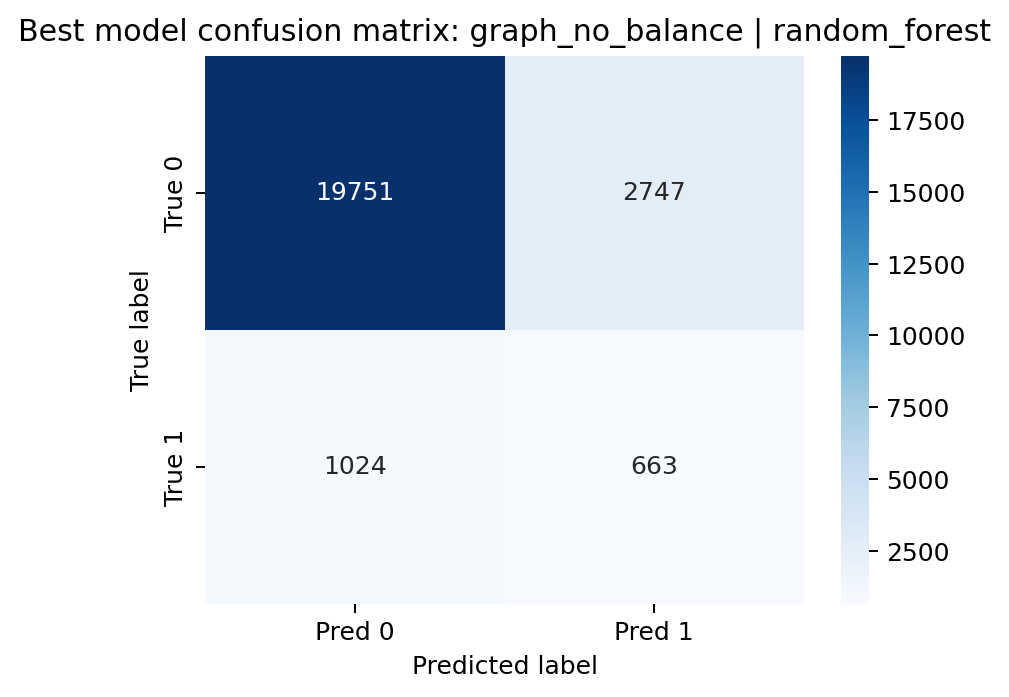

feature_importance_top20.png


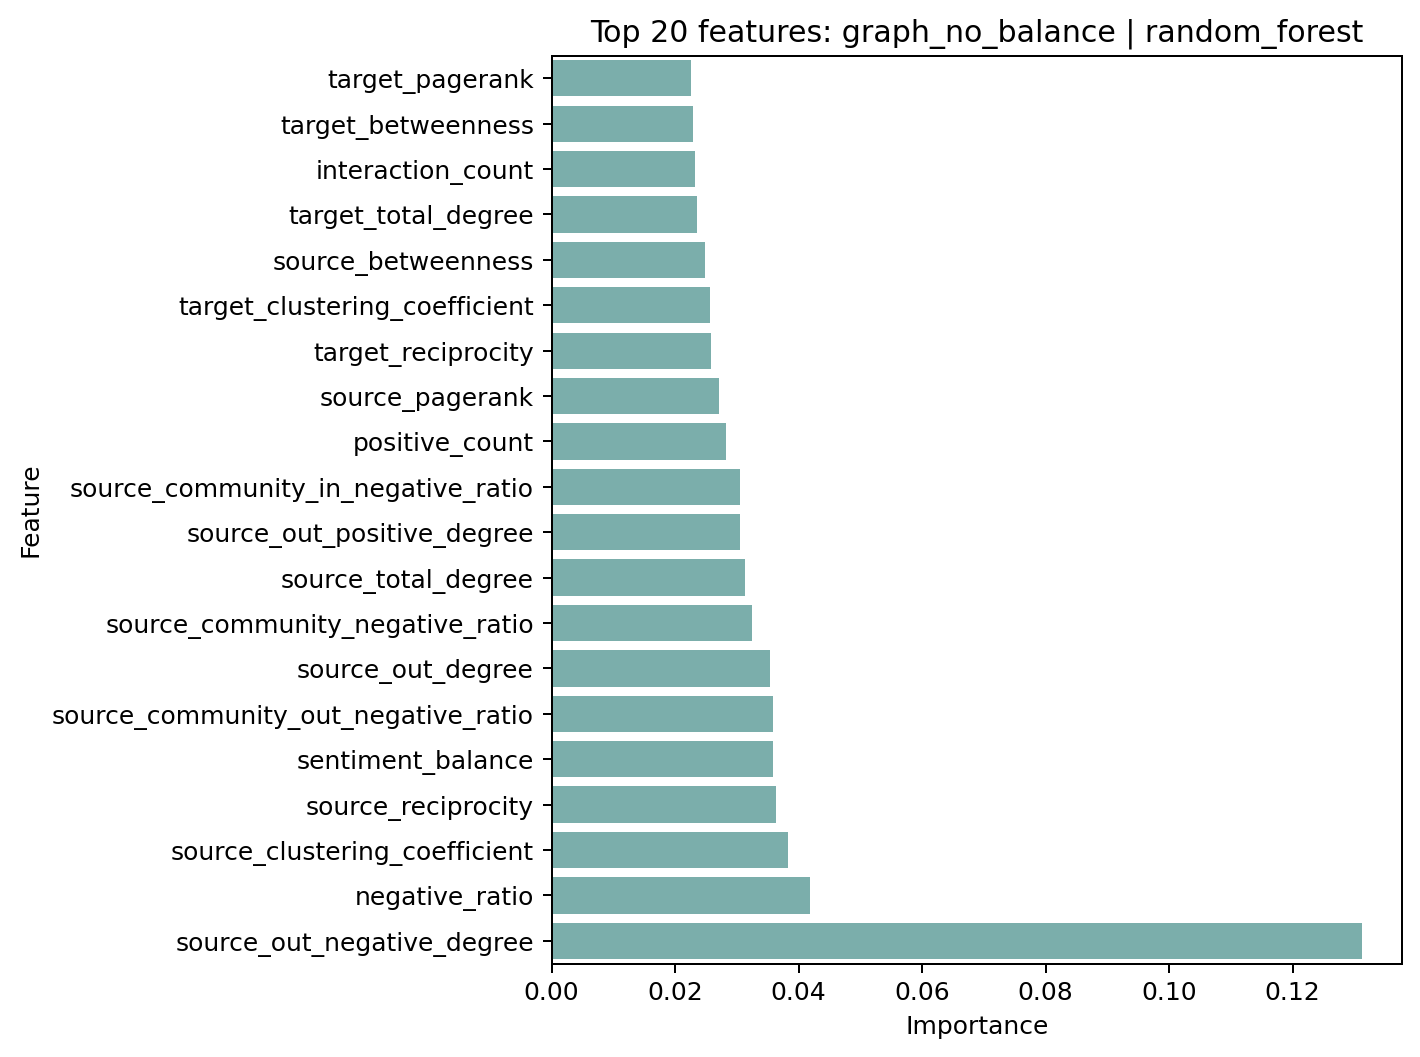

label_distribution.png


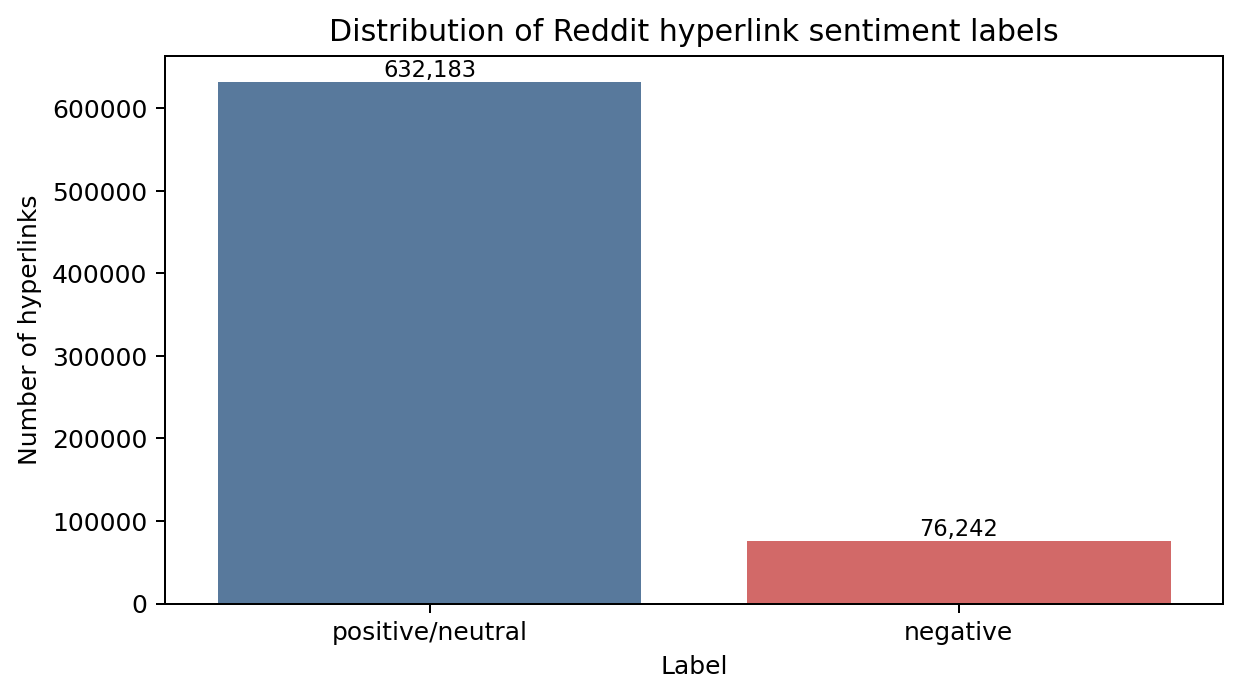

monthly_negative_ratio.png


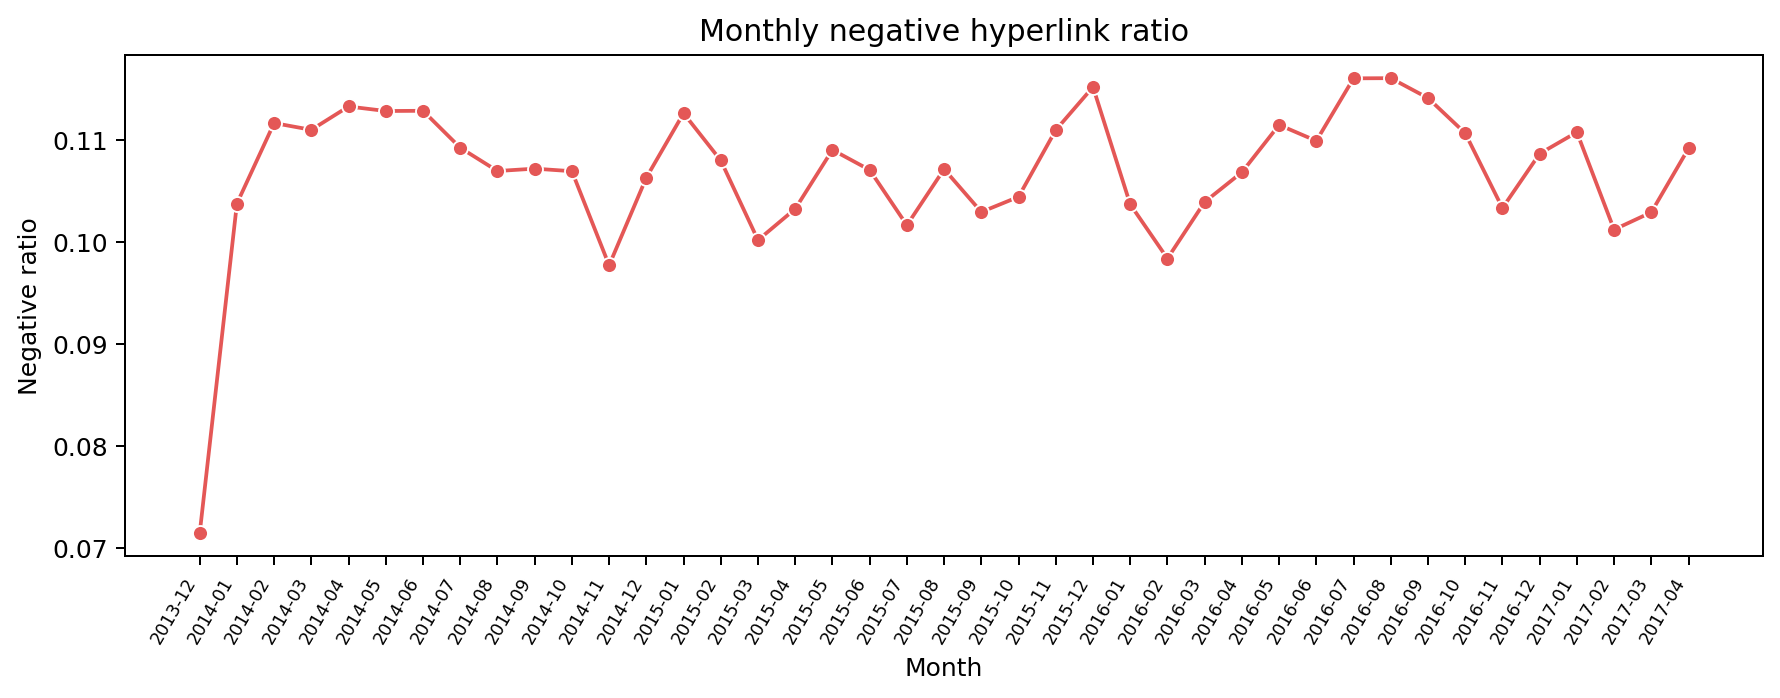

top_negative_sources.png


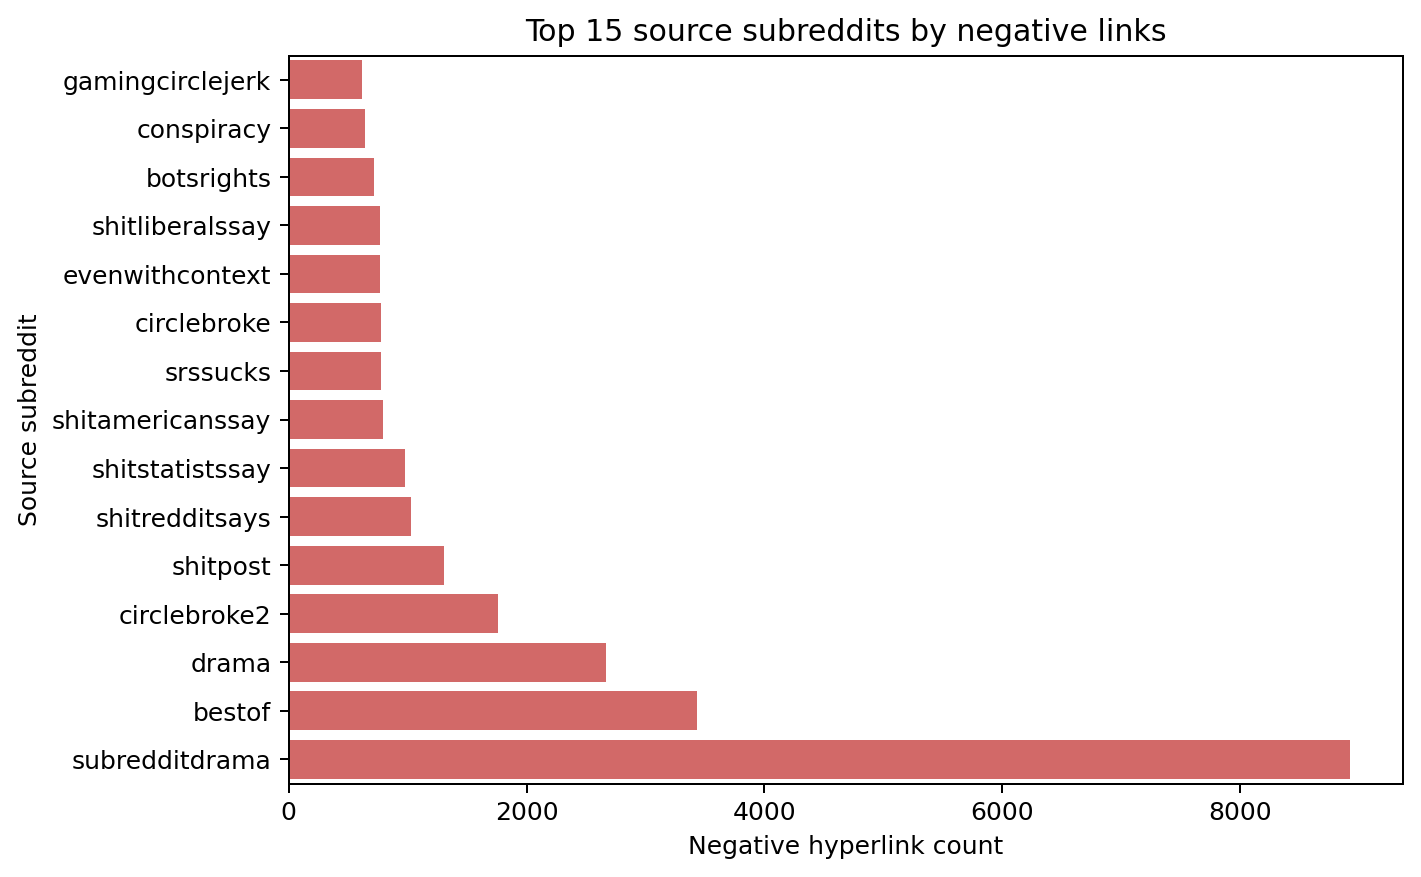

top_negative_targets.png


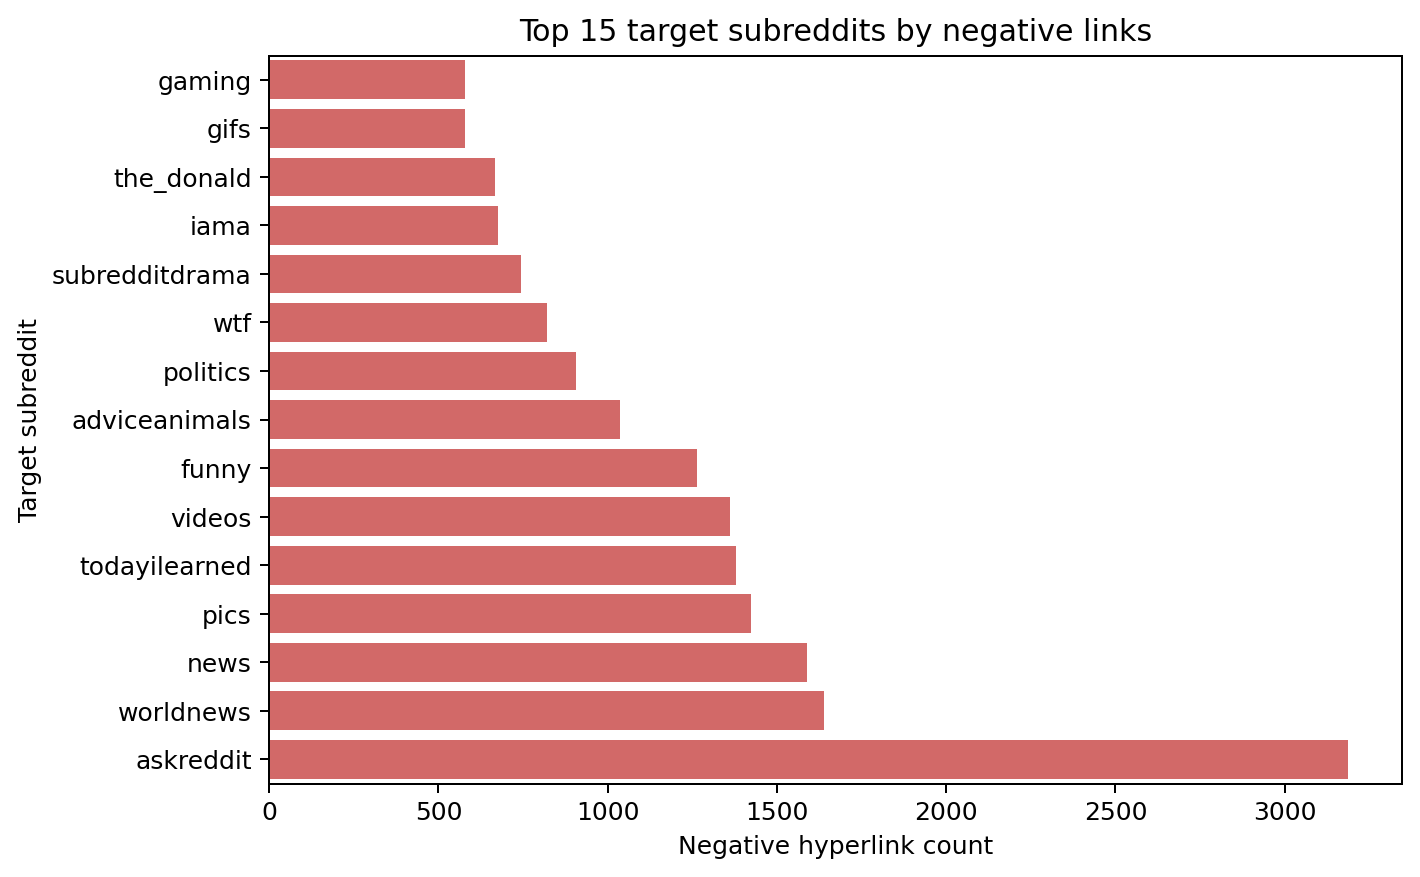

degree_distribution.png


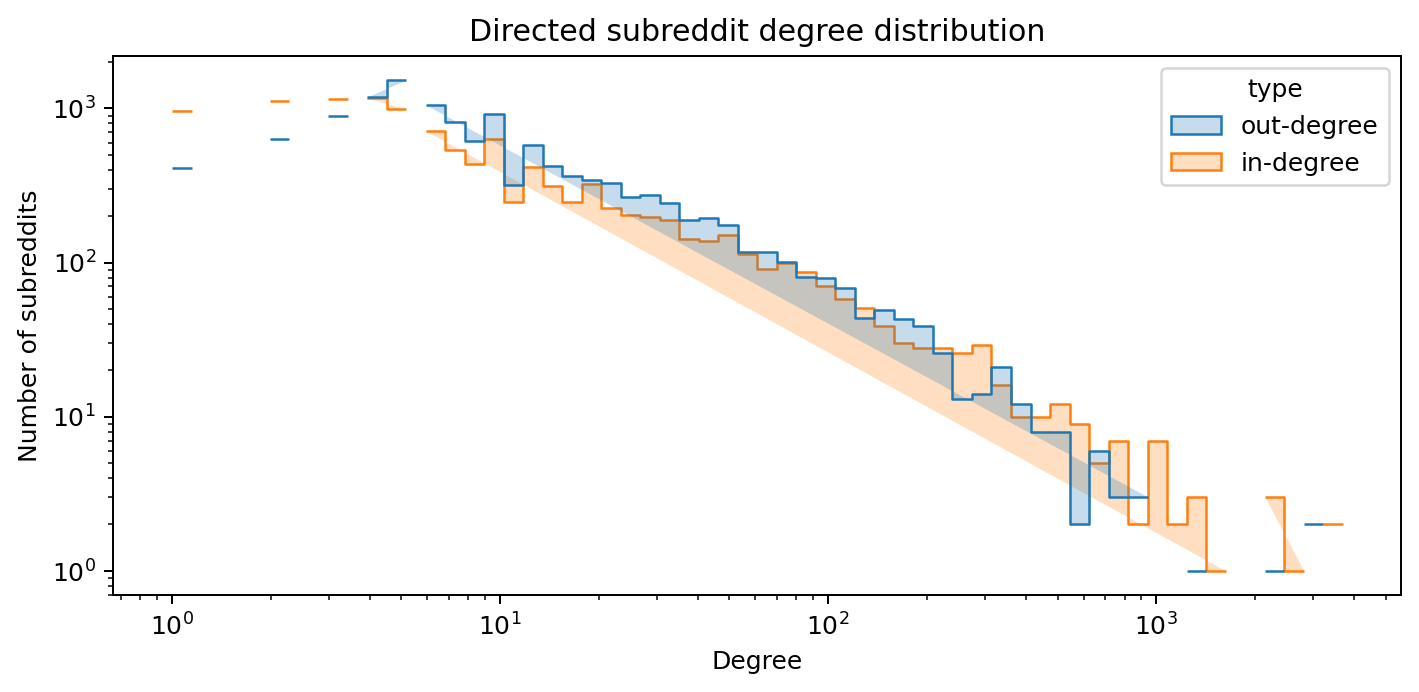

In [5]:
from IPython.display import display, Image

for image_name in [
    'model_comparison_pr_auc.png',
    'precision_recall_curve.png',
    'roc_curve.png',
    'best_confusion_matrix.png',
    'feature_importance_top20.png',
    'label_distribution.png',
    'monthly_negative_ratio.png',
    'top_negative_sources.png',
    'top_negative_targets.png',
    'degree_distribution.png',
]:
    path = figure_dir / image_name
    print(path.name)
    display(Image(filename=str(path)))